In [1]:
!pip install --quiet qdrant-client "qdrant-client[fastembed]>=1.14.2" transformers torch pillow rapidfuzz
#!pip install -q -U google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.2/396.2 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 139.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.1/324.1 kB 22.1 MB/s eta 0:00:00


In [2]:
import json
import os
import shutil
import numpy as np
import torch
from PIL import Image
from fastembed import TextEmbedding, SparseTextEmbedding
from qdrant_client import QdrantClient, models
from transformers import CLIPProcessor, CLIPModel

In [3]:
# ============================
# CONFIGURATION
# ============================
QDRANT_STORAGE = "./qdrant_store"
QUESTIONS_FILE = "questions3.json"


In [ ]:
#if we need to remove qdrant_storage
if os.path.exists(QDRANT_STORAGE):
       shutil.rmtree(QDRANT_STORAGE)
       print("🗑️ Removed existing Qdrant storage.")

In [4]:
#unzip qdrant_storage
!unzip qdrant_store_CLIP.zip

Archive:  qdrant_store_CLIP.zip
   creating: qdrant_store/
 extracting: qdrant_store/.lock      
  inflating: qdrant_store/meta.json  
   creating: qdrant_store/collection/
   creating: qdrant_store/collection/name_to_entry/
  inflating: qdrant_store/collection/name_to_entry/storage.sqlite  
   creating: qdrant_store/collection/hybrid_collection/
  inflating: qdrant_store/collection/hybrid_collection/storage.sqlite  
   creating: qdrant_store/collection/VDB_DP_IMAGES/
  inflating: qdrant_store/collection/VDB_DP_IMAGES/storage.sqlite  


In [5]:
!unzip BRRI.zip

Archive:  BRRI.zip
   creating: BRRI/Bacterial Leaf Blight/
  inflating: BRRI/Bacterial Leaf Blight/BLB_1946.jpeg  
  inflating: BRRI/Bacterial Leaf Blight/BLB_1953.jpeg  
  inflating: BRRI/Bacterial Leaf Blight/BLB_1954.jpeg  
  inflating: BRRI/Bacterial Leaf Blight/BLB_3184.jpeg  
  inflating: BRRI/Bacterial Leaf Blight/BLB_3188.jpeg  
  inflating: BRRI/Bacterial Leaf Blight/BLB_3189.jpeg  
  inflating: BRRI/Bacterial Leaf Blight/BLB_3190.jpeg  
  inflating: BRRI/Bacterial Leaf Blight/BLB_3192.jpeg  
  inflating: BRRI/Bacterial Leaf Blight/BLB_3193.jpeg  
  inflating: BRRI/Bacterial Leaf Blight/BLB_3197.jpeg  
  inflating: BRRI/Bacterial Leaf Blight/BLB_3199.jpeg  
  inflating: BRRI/Bacterial Leaf Blight/BLB_3201.jpeg  
  inflating: BRRI/Bacterial Leaf Blight/BLB_3202.jpeg  
  inflating: BRRI/Bacterial Leaf Blight/BLB_3206.jpeg  
  inflating: BRRI/Bacterial Leaf Blight/BLB_3207.jpeg  
  inflating: BRRI/Bacterial Leaf Blight/BLB_3208.jpeg  
  inflating: BRRI/Bacterial Leaf Blight/BLB_

In [6]:
from openai import OpenAI
from google.colab import userdata, files

import time
import re
import base64

# ---------------- CONFIG ----------------
or_token = userdata.get('OR_Key_2')
clientAI = OpenAI(
  base_url="https://openrouter.ai/api/v1",
  api_key=or_token,
)

#google/gemini-2.5-flash
#openai/gpt-5.2
#qwen/qwen3.7-plus
#meta-llama/llama-4-maverick

MODEL = "google/gemini-2.5-flash"


In [7]:
clientQD = QdrantClient(path="/content/qdrant_store")

In [8]:
from google.colab import userdata
HF_token = userdata.get('HF_API_Read')

dense_model_name="sentence-transformers/all-MiniLM-L6-v2"
sparse_model_name="Qdrant/bm25"

sparse_encoder = SparseTextEmbedding(model_name=sparse_model_name, token = HF_token)
dense_encoder = TextEmbedding(model_name=dense_model_name, token = HF_token)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

In [9]:
from google.colab import userdata
HF_token = userdata.get('HF_API_Read')

# =========================================================
# LOAD CLIP
# =========================================================

clip_model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32",
    token = HF_token
)

processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32",
    token = HF_token
)

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [10]:
from PIL import Image
import torch

def encode_image_clip(path):

    img = Image.open(path).convert("RGB")

    inputs = processor(
        images=img,
        return_tensors="pt"
    )

    with torch.no_grad():

        vision_outputs = clip_model.vision_model(
            pixel_values=inputs["pixel_values"]
        )

        pooled = vision_outputs.pooler_output

        feat = clip_model.visual_projection(
            pooled
        )

    feat = torch.nn.functional.normalize(
        feat,
        p=2,
        dim=-1,
    )

    feat = feat.squeeze().cpu().numpy()

    return feat.tolist()

In [11]:
import re
from rapidfuzz import process, fuzz

def correct_disease_name(predicted_name, VALID_CLASSES, threshold=80):
    """
    Corrects VLM-generated disease/pest names by
    matching them to the closest valid class name.

    Args:
        predicted_name (str): VLM output disease name.
        threshold (int): Minimum similarity score.

    Returns:
        str: Corrected disease name.
    """

    if not predicted_name:
        return predicted_name

    # Remove leading/trailing spaces
    text = predicted_name.strip()

    # Insert spaces before capital letters
    # e.g., BacterialLeaf -> Bacterial Leaf
    text = re.sub(r'(?<=[a-z])(?=[A-Z])', ' ', text)

    # Remove multiple spaces
    text = re.sub(r'\s+', ' ', text)

    # Find closest valid class
    match, score, _ = process.extractOne(
        text,
        VALID_CLASSES,
        scorer=fuzz.WRatio
    )

    # Return official class name if similarity is high enough
    if score >= threshold:
        return match

    return text

In [12]:
def describer_agent(image_path, clientAI = clientAI, model = MODEL):

  with open(image_path, "rb") as f:
            b64 = base64.b64encode(f.read()).decode("utf-8")

  prompt = """You are describing a rice plant image like a farmer reporting what is visible.
              Rules:
              1) Write only one short sentence, maximum 20 words.
              2) Describe only visible symptoms or physical damage.
              3) You must mention the affected plant part such as leaf, panicle, stem, sheath, or root in the same sentence.
              4) Mention key visible details ONLY if they are clearly visible, such as lesion color, center color, border color, color change, spot or lesion size, shape, pattern, and exact location.
              5) You may include patterns (if only clearly visible) like water-soaked marks, patchy, scraped areas, streaks, wavy edges, holes, masses, or droppings, etc.
              6) You may include shapes (if only clearly visible) like elongated, round, oval, spindle-shaped, ball, irregular, etc.
              7) Do not guess causes. Do not add background explanation.
              8) Do NOT mention lesions, spots, borders, or patterns unless they are clearly visible.
              9) Do NOT add background explanation.
              10) Do not mention any disease name.
              11) Do not mention the words disease, pest, or insect.
              12) Output only the sentence and nothing else."""

  completion = clientAI.chat.completions.create(
            model = model,
            temperature = 0.2,
            top_p = 1.0,
            messages=[
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": prompt},
                        {
                            "type": "image_url",  # Still use 'image_url', but with base64 data
                            "image_url": {
                                "url": f"data:image/jpeg;base64,{b64}"
                            }
                        }
                    ]
                }
            ]
        )

  desc = completion.choices[0].message.content

  return desc


In [13]:
from collections import defaultdict
import numpy as np
from qdrant_client import models


class RetrieverAgent:

    def __init__(
        self,
        client,
        collection_name="hybrid_collection",
        img_collection_name="VDB_DP_IMAGES",
        name_collection="name_to_entry",
        dense_encoder=None,
        sparse_encoder=None,
        image_encoder_fn=None,
        dense_vector_name="dense",
        sparse_vector_name="sparse",
        rrf_k=10,
        fusion_depth = 30,
    ):

        self.client = client

        self.collection_name = collection_name
        self.img_collection_name = img_collection_name
        self.name_collection = name_collection

        self.dense_encoder = dense_encoder
        self.sparse_encoder = sparse_encoder
        self.image_encoder_fn = image_encoder_fn

        self.dense_vector_name = dense_vector_name
        self.sparse_vector_name = sparse_vector_name

        self.rrf_k = rrf_k
        self.fusion_depth = fusion_depth

    # ============================================================
    # Individual Retrievals
    # ============================================================

    def _dense_retrieve(self, query_text):

        dense_vec = list(self.dense_encoder.embed([query_text]))[0]

        response = self.client.query_points(
            collection_name=self.collection_name,
            query=dense_vec,
            using=self.dense_vector_name,
            limit=self.fusion_depth,
        )

        # print("Dense: ")
        # print(response.points)
        # print("\n")

        return response.points

    def _sparse_retrieve(self, query_text):

        sparse_vec = list(self.sparse_encoder.embed([query_text]))[0]

        response = self.client.query_points(
            collection_name=self.collection_name,
            query=models.SparseVector(**sparse_vec.as_object()),
            using=self.sparse_vector_name,
            limit=self.fusion_depth,
        )

        # print("BM25: ")
        # print(response.points)
        # print("\n")

        return response.points

    def _image_retrieve(self, query_image_path):

        image_vec = self.image_encoder_fn(query_image_path)
        image_vec = np.array(image_vec).flatten().tolist()

        response = self.client.query_points(
            collection_name=self.img_collection_name,
            query=image_vec,
            limit=self.fusion_depth,
        )

        # print("Image: ")
        # print(response.points)
        # print("\n")

        return response.points

    # ============================================================
    # External RRF
    # ============================================================

    def _rrf_fusion(self, ranked_lists):

        fused_scores = defaultdict(float)
        point_lookup = {}

        for ranked_list in ranked_lists:

            # ----------------------------------------------------
            # Keep BEST point per disease for this retrieval branch
            # ----------------------------------------------------
            best_per_name = {}

            for point in ranked_list:

                payload = point.payload or {}

                key = payload.get("name", "")

                if key == "":
                    continue

                if (
                    key not in best_per_name
                    or point.score > best_per_name[key].score
                ):
                    best_per_name[key] = point

            # ----------------------------------------------------
            # Apply RRF using disease-level ranking
            # ----------------------------------------------------
            deduped_points = sorted(
                best_per_name.values(),
                key=lambda x: x.score,
                reverse=True,
            )

            for rank, point in enumerate(deduped_points, start=1):

                key = point.payload.get("name", "")

                fused_scores[key] += 1.0 / (self.rrf_k + rank)

                # keep best overall representative point
                if (
                    key not in point_lookup
                    or point.score > point_lookup[key].score
                ):
                    point_lookup[key] = point

        # --------------------------------------------------------
        # Final fused ranking
        # --------------------------------------------------------
        ranked_items = sorted(
            fused_scores.items(),
            key=lambda x: x[1],
            reverse=True,
        )

        fused_points = []

        for key, fused_score in ranked_items[:self.fusion_depth]:

            point = point_lookup[key]

            point.score = float(fused_score)

            fused_points.append(point)

        return fused_points

    # ============================================================
    # Hybrid Retrieval Variants
    # ============================================================

    def _hybrid_retrieve(self, query_text):

        dense_points = self._dense_retrieve(query_text)

        sparse_points = self._sparse_retrieve(query_text)

        return self._rrf_fusion(
            [dense_points, sparse_points],
        )

    def _dense_image_retrieve(
        self,
        query_text,
        query_image_path,
    ):

        dense_points = self._dense_retrieve(
            query_text
        )

        image_points = self._image_retrieve(
            query_image_path
        )

        return self._rrf_fusion(
            [dense_points, image_points]
        )

    def _sparse_image_retrieve(
        self,
        query_text,
        query_image_path
    ):

        sparse_points = self._sparse_retrieve(
            query_text
        )

        image_points = self._image_retrieve(
            query_image_path
        )

        return self._rrf_fusion(
            [sparse_points, image_points]
        )

    def _full_mm_retrieve(
        self,
        query_text,
        query_image_path,
    ):

        dense_points = self._dense_retrieve(
            query_text
        )

        sparse_points = self._sparse_retrieve(
            query_text
        )

        image_points = self._image_retrieve(
            query_image_path
        )

        return self._rrf_fusion(
            [
                dense_points,
                sparse_points,
                image_points,
            ]
        )

    # ============================================================
    # Post Processing
    # ============================================================

    def _process_results(self, points, top_k):

        best_by_name = {}

        for point in points:

            payload = point.payload or {}

            name = payload.get("name", "unknown")
            typ = payload.get("type", "unknown")
            text = payload.get("text", "").strip()

            if (
                name not in best_by_name
                or point.score > best_by_name[name]["score"]
            ):

                best_by_name[name] = {
                    "id": point.id,
                    "score": point.score,
                    "name": name,
                    "type": typ,
                    "matched_sentence": text,
                }

        return sorted(
            best_by_name.values(),
            key=lambda x: x["score"],
            reverse=True,
        )[:top_k]

    # ============================================================
    # Metadata Attachment
    # ============================================================

    def _attach_metadata(self, results):

        for result in results:

            name = result["name"]

            if name == "unknown":

                result["sections_text"] = ""
                result["visual_symptoms"] = ""

                continue

            name_result = self.client.query_points(
                collection_name=self.name_collection,
                query_filter=models.Filter(
                    must=[
                        models.FieldCondition(
                            key="name",
                            match=models.MatchValue(value=name),
                        )
                    ]
                ),
                limit=1,
            )

            if name_result.points:

                payload = name_result.points[0].payload

                result["sections_text"] = payload.get(
                    "sections_text",
                    "",
                )

                result["visual_symptoms"] = payload.get(
                    "visual_symptoms",
                    "",
                )

            else:

                result["sections_text"] = ""
                result["visual_symptoms"] = ""

        return results

    # ============================================================
    # Public Retrieval API
    # ============================================================

    def retrieve(self, query_text = None, query_image_path = None, top_k=10):
        """
        Automatically selects:
            - hybrid retrieval (if both encoders)
            - dense retrieval (if only dense encoder)
            - sparse retrieval (if only sparse encoder)
        """

        if self.dense_encoder and self.sparse_encoder and self.image_encoder_fn:
            points = self._full_mm_retrieve(query_text, query_image_path)

        elif self.dense_encoder and self.sparse_encoder:
            points = self._hybrid_retrieve(query_text)

        elif self.dense_encoder and self.image_encoder_fn:
            points = self._dense_image_retrieve(query_text, query_image_path)

        elif self.sparse_encoder and self.image_encoder_fn:
            points = self._sparse_image_retrieve(query_text, query_image_path)

        elif self.dense_encoder:
            points = self._dense_retrieve(query_text)

        elif self.sparse_encoder:
            points = self._sparse_retrieve(query_text)

        elif self.image_encoder_fn:
            points = self._image_retrieve(query_image_path)

        else:
            raise ValueError("No encoder available! Provide dense or sparse encoder.")

        results = self._process_results(points, top_k)
        results = self._attach_metadata(results)

        return results

In [26]:
def retrieve_question_by_candidate(candidate, question_file="questions3.json"):
    with open(question_file, "r", encoding="utf-8") as f:
        question_data = json.load(f)

    candidate = candidate.strip()

    for item in question_data:
        if item["name"].strip() == candidate:
            return item["set_a"][0]

    return None

def questioning_agent(image_path, results, clientAI = clientAI, MODEL = MODEL):

    ques_count = 0
    # ---------------- STEP 0: Common pest identification ----------------
    if not results:
        print("⚠️ No candidates available.")
        return None

    # ---------------- STEP 1: Prepare candidates ----------------
    candidates = [r["name"] for r in results]
    #preserve valid class names
    valid_classes = []
    valid_classes = candidates

    if not candidates:
        print("⚠️ No candidates with question sets found.")
        return None

    matched_sentence_list = [
      {"name": r["name"], "matched_sentence": r["matched_sentence"]}
      for r in results
    ]
    sections_text_list = [
      {"name": r["name"], "type": r["type"], "sections_text": r["sections_text"]}
      for r in results
    ]

    visual_symptoms_list = [
      {"name": r["name"], "type": r["type"], "visual_symptoms": r["visual_symptoms"]}
      for r in results
    ]

    visual_dict = {d["name"]: d["visual_symptoms"] for d in visual_symptoms_list}


    print("Now you can answer (options: 'yes', 'no')\n")
    # ---------------- STEP 2: Main diagnosis loop ----------------
    system_prompt = (
    "You are an agricultural diagnosis assistant for rice crops. "
    "Follow the user-provided rules exactly and do not introduce your own decision criteria."
)

    with open(image_path, "rb") as f:
          b64 = base64.b64encode(f.read()).decode("utf-8")


    confirmed = None
    conversation_history = []
    asked = []
    rejected_list = []
    current_candidate = None
    question_to_ask = None
    decision = None
    reasoning = ""
    while candidates:

        if current_candidate != None:
            visual_symptoms = visual_dict[current_candidate]

            vlm_reasoning_prompt = f"""Current candidate: {current_candidate}
                          Visual context for the candidate: {visual_symptoms}
                          Farmer's answers so far: {list(zip(asked, conversation_history))}

                          Consider the context provided above.

                          Evidence hierarchy:
                          Farmer answers carry greater importance than image information and must guide the decision.
                          Image information may be used only to support or question conclusions drawn from farmer answers, but must not override a clear farmer answer.
                          Do not reinterpret or soften a clear denial using image information.

                          Your task:
                          1) Review the image to understand the visual context.
                          2) Analyze the question(s) and their relevant farmer’s answer(s) so far.
                          2) Use image information only as supporting context when interpreting farmer answers.
                          3) Decide whether the combined evidence supports or contradicts the current candidate, giving priority to farmer answers when evidence conflicts.
                          4) You must not guess or decide based on image information alone.
                          5) You must output exactly one decision: [confirm] or [reject].
                          6) Reasoning must contain at most five complete sentences in plain text.
                          7) Do not use any formatting symbols such as **, *, _, backticks, or bullets.

                          Output format:
                          Reasoning: <plain text reasoning>
                          Decision: [confirm] or [reject]
                          Name: <candidate name>
                          """

            #print(vlm_reasoning_prompt)


            messages = [
                {
                    "role": "system",
                    "content": system_prompt
                },
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": vlm_reasoning_prompt},
                        {
                            "type": "image_url",  # Still use 'image_url', but with base64 data
                            "image_url": {
                                "url": f"data:image/jpeg;base64,{b64}"
                            }
                        }
                    ]
                }
            ]

            #time.sleep(5)

            response = clientAI.chat.completions.create(
                          model=MODEL,
                          temperature = 0.0,
                          top_p = 1.0,
                          messages=messages
                      )
            vlm_response = response.choices[0].message.content.strip()


            for line in vlm_response.split("\n"):
                if "confirm" in line.lower():
                    decision = "confirm"
                elif "reject" in line.lower():
                    decision = "reject"
                elif "continue" in line.lower():
                    decision = "continue"
                if line.lower().startswith("name:"):
                    candidate_name = line.split(":", 1)[1].strip().strip("'").strip('"')
                    current_candidate = candidate_name
                if line.lower().startswith("reasoning:"):
                    reasoning = line.split(":", 1)[1].strip()

            if decision == "confirm":
                candidate_info = next(
                              (
                                  {"name": r["name"], "type": r["type"], "reasoning": reasoning, "sections_text": r["sections_text"]}
                                  for r in sections_text_list
                                  if r["name"].lower() == candidate_name.lower()
                              ),
                              None  # default if not found
                          )
                confirmed = {
                    "name": candidate_info["name"],
                    "type": candidate_info["type"],
                    "reasoning": candidate_info["reasoning"],
                    "sections_text": candidate_info["sections_text"],
                    "no_ques": ques_count
                }
                print(f"✅ Confirmed: {candidate_info['name']} ({candidate_info['type']})\n")
                print(f"❓ Question count: {ques_count}\n")
                #candidate_done = True
                #break
            elif decision == "reject":
                print(f"❌ Rejected: {candidate_name}\n")

                if candidate_name in candidates:
                    candidates.remove(candidate_name)

                visual_symptoms_list = [
                    item for item in visual_symptoms_list
                    if item["name"] != candidate_name
                  ]

            if confirmed:
              break

        # decision = None or reject
        if decision != "confirm":
            if ques_count >= 5:
                print(f"Maximum {ques_count} Questions!!!")
                print("\n⚠️ No disease or pest confirmed after evaluation. Please take a closer and clearer picture. If decision can not be made after multiple tries, please contact a human expert.")
                return {"name": "No Class", "no_ques": ques_count, "reasoning": "No disease or pest confirmed after evaluation."}


            candidate_selection_prompt = f"""Candidate list (ranked): {candidates}
                                              Visual context for each candidate: {visual_symptoms_list}
                                              Farmer's answers so far: {list(zip(asked, conversation_history))}

                                              Consider only the context provided above.

                                              IMPORTANT: You must output ONLY the candidate name exactly as listed in the candidate list.
                                              Do NOT output any reasoning, explanation, step-by-step text, or extra characters.
                                              Do NOT add anything before, after, or around the candidate name.

                                              Selection rules:
                                              A. Use the image and visual context as the primary basis for selection.
                                              B. Give strong priority to candidates whose affected plant part matches the visible symptom location.
                                              For example, if symptoms are mainly on leaves, prefer leaf diseases or leaf pest damage over panicle or stem diseases.
                                              C. The ranking provides a relevance prior and should influence your choice.
                                              D. Prefer higher-ranked candidates when they are reasonably consistent with the image.
                                              E. Select a lower-ranked candidate only if it matches the image and plant part clearly better.
                                              F. If the image is unclear or symptoms are partially visible, rely more on plant part match and overall similarity.
                                              G. Do not require every listed symptom to be visible.
                                              H. You must select exactly one candidate from the provided candidate list.
                                              I. You are not allowed to answer no match, unknown, or none.
                                              J. You must not invent or output any name that is not in the candidate list.
                                              K. Even if the image is unclear, choose the closest matching candidate from the list.

                                              Your task (for internal reasoning only):
                                              1) Review the image to identify the main affected plant part and visible symptoms.
                                              2) Compare with each candidate’s visual context.
                                              3) Select the most relevant candidate from the provided candidate list using best visual similarity to the described symptoms, plant part match, and ranking preference.
                                              4) Exact symptom match is not required; partial or approximate similarity is acceptable.
                                              5) Do not perform reasoning or make any diagnosis decision.
                                              6) Output only the selected candidate name.

                                              Output format (strict):
                                              Candidate: <selected candidate name>
                                              No other text is allowed.
                                              """

            #print(candidate_selection_prompt)

            messages = [
                {
                    "role": "system",
                    "content": system_prompt
                },
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": candidate_selection_prompt},
                        {
                            "type": "image_url",  # Still use 'image_url', but with base64 data
                            "image_url": {
                                "url": f"data:image/jpeg;base64,{b64}"
                            }
                        }
                    ]
                }
            ]

            #time.sleep(5)

            response = clientAI.chat.completions.create(
                          model=MODEL,
                          temperature = 0.0,
                          top_p = 1.0,
                          messages=messages
                      )
            vlm_response = response.choices[0].message.content.strip()

            candidate_name = vlm_response.strip().strip("'").strip('"')

            if vlm_response.lower().startswith("candidate:"):
                  candidate_name = vlm_response.split(":", 1)[1].strip().strip("'").strip('"')

            candidate_name = correct_disease_name(candidate_name, valid_classes)
            current_candidate = candidate_name
            #retrieving question
            question_to_ask = retrieve_question_by_candidate(candidate_name)

            ques_count += 1
            print(f"❓ Question count: {ques_count}\n")
            farmer_ans = input(f"❓ {question_to_ask}\nFarmer: ").strip().lower()

            asked.append(f"Question for candidate {current_candidate}: {question_to_ask}")
            conversation_history.append(f"Farmer's answer: {farmer_ans}")

    if not confirmed:
        print("\n⚠️ No disease or pest confirmed after evaluation. Please take a closer and clearer picture. If decision can not be made after multiple tries, please contact a human expert.")
        return None

    return confirmed

In [18]:
def build_context_for_entity(candidate_type, predicted, raw_reasoning, knowledge):
    """
    Build a text context for a single entity (disease or pest) from its sections.

    Parameters:
    - entity_type: str, e.g., "disease" or "pest"
    - entity_name: str, e.g., "Bacterial Leaf Blight"
    - all_sections: str

    Returns:
    - str: full context text suitable for LLM
    """
    lines = [f"Candidate Type: {candidate_type}", f"Predicted: {predicted}", f"Raw Reasoning: {raw_reasoning}", ""]
    lines.append(knowledge)

    return "\n".join(lines)

def advisory_agent(context_text, clientAI = clientAI, MODEL = MODEL):

  system_prompt = (
      "You are an agricultural assistant helping rice farmers. "
      "Use only the information provided in the context.\n\n"
      f"Context:\n{context_text}\n\n"
      "If the answer cannot be found in the context, reply: "
      "'Please contact a human expert.'"

  )

  vlm_prompt = (
      "Based on the confirmed diagnosis in the context, provide a short explanation for the farmer.\n\n"

      "Your response should include:\n"
      "1. What is likely affecting the plant.\n"
      "2. Why you think this is the problem.\n"
      "3. What the farmer should do next.\n\n"

      "For the reason:\n"
      "- Use information from both the farmer's observations and the image-related observations.\n"
      "- Mention only evidence supporting the diagnosed problem.\n"
      "- Do not discuss diseases that were ruled out.\n"
      "- Explain the reason in simple everyday language.\n\n"

      "For the advice:\n"
      "- Use the information provided in the context.\n"
      "- Give practical actions the farmer can take.\n"
      "- Do not invent recommendations.\n\n"

      "Use simple, natural language that a farmer can easily understand.\n"
      "Avoid scientific or technical terms whenever possible.\n"
      "Keep the response concise.\n"
      "Start with a friendly sentence."
  )

  #print(system_prompt)
  messages = [
                {
                    "role": "system",
                    "content": system_prompt
                },
                {
                    "role": "user",
                    "content": vlm_prompt
                }
            ]

  response = clientAI.chat.completions.create(
                          model=MODEL,
                          temperature = 0.4,
                          top_p = 0.9,
                          messages=messages
                      )
  return response.choices[0].message.content.strip()


In [27]:
#RICE-CARE Framework
def symptom_description_generation(image_path, clientAI, model):
  return describer_agent(image_path, clientAI, model)

def candidate_and_knowledge_retrieval(image_path, sym_desc):
  retriever = RetrieverAgent(
    client=clientQD,
    dense_encoder=dense_encoder,
    image_encoder_fn=encode_image_clip,
  )

  results = retriever.retrieve(sym_desc, image_path, top_k=10)
  return results

def human_in_the_loop_reasoning(image_path, retrieved_results, clientAI, model):
  return questioning_agent(image_path, retrieved_results, clientAI, model)

def rationale_advice_generation(ctype, predicted, raw_reasoning, knowledge, clientAI, model):
  context = build_context_for_entity(ctype, predicted, raw_reasoning, knowledge)
  return advisory_agent(context, clientAI, model)

In [20]:
#create excel file to keep records for each image  of the dataset
import os
import pandas as pd

root_dir = "BRRI"
csv_path = "/content/results_gemini-2.5-flash.csv"


# Create only if file does not exist
if not os.path.exists(csv_path):

    rows = []
    IMAGE_EXTENSIONS = {
        ".jpg", ".jpeg", ".png", ".bmp",
        ".tif", ".tiff", ".webp"
    }

    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)

        if os.path.isdir(class_path):
            for fname in os.listdir(class_path):
                file_path = os.path.join(class_path, fname)
                ext = os.path.splitext(fname)[1].lower()

                if os.path.isfile(file_path) and ext in IMAGE_EXTENSIONS:
                    rows.append({
                        "file_name": fname,
                        "name": class_name,
                        "type": "",
                        "desc": "",
                        "actual": "",
                        "predicted": "",
                        "no_ques": "",
                        "raw_reasoning": "",
                        "rationale_advice": "",
                    })

    df = pd.DataFrame(rows)
    df = df.sort_values(by=["name", "file_name"])
    df.to_csv(csv_path, index=False)

    print("CSV created:", csv_path, "| rows:", len(df))

else:
    print("CSV already exists — skipped creation.")


CSV created: /content/results_gemini-2.5-flash.csv | rows: 569


In [21]:
import pandas as pd

# Load the CSV
csv_path = "/content/results_gemini-2.5-flash.csv"
df = pd.read_csv(csv_path)

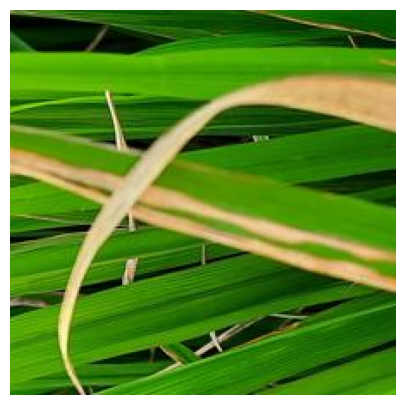

Now you can answer (options: 'yes', 'no')

❓ Question count: 1

❓ Do you see any one of these sets of signs on the rice leaves?
Set 1:
1) Light tan or dark brown spots.
2) The spots have ring-like patterns.
Set 2:
1) Gray-green, water-soaked spots.
2) The spots are near the leaf tip or edge.
Set 3:
1) Large burned-looking patches.
2) The patches have a sharp dark brown or reddish-brown edge.
Farmer: no
❌ Rejected: Leaf Scald

❓ Question count: 2

❓ Do you see any one of these sets of signs on the rice leaves?
Set 1:
1) Long continuous marks that are yellow to light brown, or whitish.
2) These marks are along the edge or middle of the leaf.
Set 2:
1) Water-soaked marks.
2) These marks are light green or grayish green.
Farmer: yes
✅ Confirmed: Bacterial Leaf Blight (disease)

❓ Question count: 2

Rationale and Advice: 


  Hello there!

It looks like your rice plants are suffering from **Bacterial Leaf Blight** (Patapora Rog).

We think this is the problem because you mentioned seeing ye

/tmp/ipykernel_1437/3194812759.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Bacterial Leaf Blight' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[loc, "actual"] = class_dir
/tmp/ipykernel_1437/3194812759.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Bacterial Leaf Blight' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[loc, "predicted"] = confirmed_case["name"]
/tmp/ipykernel_1437/3194812759.py:31: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'disease' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[loc, "type"] = confirmed_case["type"]
/tmp/ipykernel_1437/3194812759.py:33: Futu

In [28]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

loc = 0 #row number of the excel. Each row contains file_name(image file name) and name(class folder), etc.
#print(loc)
class_dir = df["name"].iloc[loc]
file_name = df["file_name"].iloc[loc]
class_folder = f"/content/{root_dir}/{class_dir}"
image_path = os.path.join(class_folder, file_name)
img = mpimg.imread(image_path)
plt.figure(figsize=(7, 5))
plt.imshow(img)
plt.axis("off")   # hide axes
plt.show()

sym_desc = symptom_description_generation(image_path, clientAI, MODEL)
#print(sym_desc)

df.loc[loc, "desc"] = sym_desc
df.to_csv(csv_path, index=False)

results = candidate_and_knowledge_retrieval(image_path, sym_desc)
#print(results)

confirmed_case = human_in_the_loop_reasoning(image_path, results, clientAI, MODEL)
#print(confirmed_case)

df.loc[loc, "actual"] = class_dir
df.loc[loc, "predicted"] = confirmed_case["name"]
df.loc[loc, "type"] = confirmed_case["type"]
df.loc[loc, "no_ques"] = confirmed_case["no_ques"]
df.loc[loc, "raw_reasoning"] = confirmed_case["reasoning"]
df.to_csv(csv_path, index=False)

knowledge = next(
    (item.get("sections_text", "")
     for item in results
     if item.get("name") == confirmed_case["name"]),
    ""
)
rationale_advice = rationale_advice_generation(confirmed_case["type"], confirmed_case["name"], confirmed_case["reasoning"], knowledge, clientAI, MODEL)
print("Rationale and Advice: \n")
print(rationale_advice)
df.loc[loc, "rationale_advice"] = rationale_advice
df.to_csv(csv_path, index=False)